In [1]:
!pip install -r requirements.txt

In [2]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
                                classification_report,
                                confusion_matrix,
                                roc_auc_score,
                                roc_curve,
                                precision_recall_curve,
                                f1_score,
                              precision_score,
                                recall_score,
                                accuracy_score

                            )
warnings.filterwarnings('ignore')

Load the data

In [3]:
X_train = np.load('../artifacts/x_train.npz')['arr_0']
Y_train = np.load('../artifacts/y_train.npz')['arr_0']
X_test = np.load('../artifacts/x_test.npz')['arr_0']
Y_test = np.load('../artifacts/y_test.npz')['arr_0']

In [4]:
model_lr = LogisticRegression(
                                random_state =42,
                                max_iter = 1000
                                )
model_lr.fit(X_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Inference

In [5]:
Y_hat_train = model_lr.predict(X_train)
Y_hat_test = model_lr.predict(X_test)

In [6]:
Y_proba_train = model_lr.predict_proba(X_train)
Y_proba_test = model_lr.predict_proba(X_test)
Y_proba_train

array([[0.9239779 , 0.0760221 ],
       [0.6367169 , 0.3632831 ],
       [0.75965271, 0.24034729],
       ...,
       [0.27245676, 0.72754324],
       [0.43561915, 0.56438085],
       [0.58928312, 0.41071688]], shape=(12712, 2))

Evaluation

In [7]:
pd.Series(Y_train).value_counts()

0    6356
1    6356
Name: count, dtype: int64

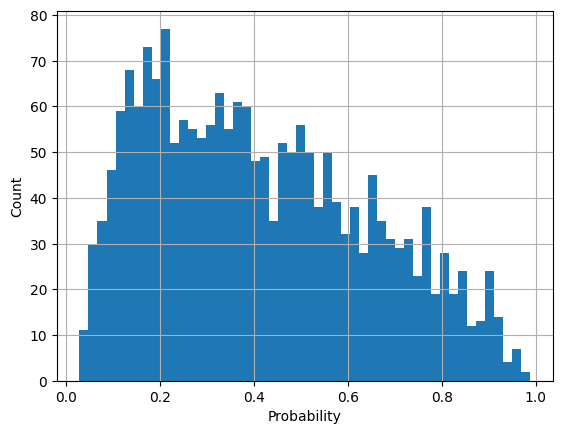

In [14]:
Y_lr_test = Y_proba_test[:, 1]
plt.hist(Y_lr_test,bins=50)
plt.xlabel('Probability')
plt.ylabel('Count')
plt.grid(True)
plt.show()

In [19]:
Y_hat_test = Y_lr_test > 0.8

In [20]:
cm = confusion_matrix(Y_test,Y_hat_test)

In [21]:
cm

array([[1552,   55],
       [ 306,   87]])

Text(50.722222222222214, 0.5, 'Actual')

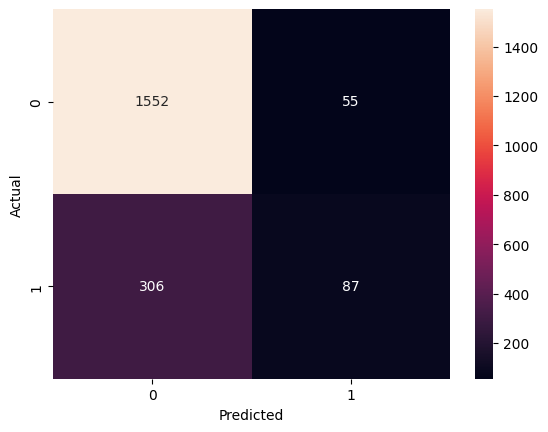

In [22]:
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')